In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
hbar = 6.582e-22
def read_file(data_file):
    data = np.loadtxt(data_file, delimiter=',')
    time = data[:,0] * hbar * 1e6
    rho = data[:,2:2+4*206]
    rhobar = data[:,2+206*4:-2]
    P0 = rho[:,::4]
    Pz = rho[:,3::4]

    P0bar = rhobar[:,::4]
    Pzbar = rhobar[:,3::4]

    f_e = 0.5*P0*(1+Pz)
    f_m = 0.5*P0*(1-Pz)

    f_ebar = 0.5*P0bar*(1+Pzbar)
    f_mbar = 0.5*P0bar*(1-Pzbar)

    return time, f_e, f_m, f_ebar, f_mbar, rho, rhobar

GF = 1.166e-11
Tcm = 32
def V_mat(data, eps_data):
    eps = eps_data[0,:]
    w = eps_data[1,:]
    rho = data[-2]
    rhobar = data[-1]

    P0 = rho[:,::4]
    Px = rho[:,1::4]
    Py = rho[:,2::4]
    Pz = rho[:,3::4]
    
    P0bar = rhobar[:,::4]
    Pxbar = rhobar[:,1::4]
    Pybar = rhobar[:,2::4]
    Pzbar = rhobar[:,3::4]   

    Vx = 0.5 * P0 * Px - 0.5 * P0bar * Pxbar
    Vy = 0.5 * P0 * Py - 0.5 * P0bar * Pybar
    Vz = 0.5 * P0 * Pz - 0.5 * P0bar * Pzbar

    z = np.zeros(len(Vz))
    y = np.zeros(len(Vz))
    x = np.zeros(len(Vz))

    res = np.zeros((3, len(Vz)))
    for i in range(len(z)):
        zz = Vz[i,:] * eps**2
        yy = Vy[i,:] * eps**2
        xx = Vx[i,:] * eps**2
        res[2,i] = np.sum(w * zz)
        res[1,i] = np.sum(w * yy)
        res[0,i] = np.sum(w * xx)

    return np.sqrt(2) * GF * Tcm**3 * res

def s_classical(fe, fm, eps, w):
    se = np.zeros(len(eps))
    for i in range(len(se)):
        if fe[i] > 0 and fe[i] < 1:
            se[i] += fe[i] * np.log(fe[i]) + (1-fe[i]) * np.log(1-fe[i])
        if fm[i] > 0 and fm[i] < 1:
            se[i] += fm[i] * np.log(fm[i]) + (1-fm[i]) * np.log(1-fm[i])
    se *= -eps**2 / (2 * np.pi**2)

    return np.sum(se * w)

def s_quantum(r, eps, w):
    se = np.zeros(len(eps))
    for i in range(len(se)):
        den = r[4*i:4*i+4]
        lam1 = 0.5 * den[0] + 0.5 * den[0] * np.sqrt(np.sum(den[1:]**2))
        lam2 = 0.5 * den[0] - 0.5 * den[0] * np.sqrt(np.sum(den[1:]**2))

        if lam1 > 0 and lam1 < 1:
            se[i] += lam1 * np.log(lam1) + (1-lam1) * np.log(1-lam1)
        if lam2 > 0 and lam2 < 1:
            se[i] += lam2 * np.log(lam2) + (1-lam2) * np.log(1-lam2)

    se *= -eps**2 / (2 * np.pi**2)
    return np.sum(se * w)

def entropy(data, eps_data):
    fe = data[1]
    fm = data[2]
    rho = data[3]
    eps = eps_data[0,:]
    w = eps_data[1,:]
    s = np.zeros(len(fe[:,0]))
    sq = np.zeros_like(s)

    for i in range(len(s)):
        s[i] = s_classical(fe[i,:], fm[i,:], eps, w)
        sq[i] = s_quantum(rho[i,:], eps, w)

    return s, sq

def osc_frequency(data_file, eps_data, only_peaks=False):
    t = data_file[0]
    V = V_mat(data_file, eps_data)
    dv = np.diff(V[1,:])
    
    t_max = []
    t_min = []

    for i in range(len(dv)-1):
        if dv[i] * dv[i+1] < 0:
            t_zero = t[i] - dv[i] * (t[i+1]-t[i])/(dv[i+1]-dv[i])
            if dv[i] > 0:
                t_max.append(t_zero)
            else:
                t_min.append(t_zero)

    t_extrema = np.array(t_max+t_min)
    t_extrema.sort()

    if(only_peaks):
        return np.array(t_max), 2*np.pi / np.diff(t_max)
    else:
        return np.array(t_extrema), np.pi / np.diff(t_extrema)

def num_density(data, eps_file):
    eps = eps_data[0,:]
    w = eps_data[1,:]

    dn = np.zeros((4,len(data[0]),len(eps)))
    for i in range(4):
        for j in range(len(data[0])):
            dn[i,j,:] = data[i+1][j,:] * eps**2 / (2 * np.pi**2)

    n = np.zeros((4, len(data[0])))
    for i in range(4):
        for j in range(len(data[0])):
            n[i,j] = np.sum(dn[i,j,:] * w)

    return n * Tcm**3

In [3]:
index_plots = [15, 45]
e_color = '#008185'
m_color = '#5CBE00'

def ic_plot(data, eps_data, eps_max=6, file_name =None):
    eps = eps_data[0]
    plt.figure(figsize=(5,2))
    plt.plot(eps, eps**2 / (2 * np.pi**2) * data[1][0,:], c=e_color, lw=2, label=r"$\nu_e, \bar\nu_e$")
    plt.plot(eps, eps**2 / (2 * np.pi**2) * data[2][0,:], c=m_color, lw=2, ls="--", label=r"$\nu_\mu, \bar\nu_\mu$")
    plt.xlim(0, eps_max)
    plt.ylim(0, max(np.max(eps**2 / (2 * np.pi**2) * data[1][0,:]), np.max(eps**2 / (2 * np.pi**2) * data[2][0,:]))*1.1)
    plt.legend()

    plt.xlabel(r"$\epsilon$", fontsize=12)
    plt.ylabel(r"$dn/d\epsilon$ [arb.units]", fontsize=12)

    plt.axvline(eps[index_plots[0]], c='0.50', ls=":")
    plt.axvline(eps[index_plots[1]], c='0.50', ls=":")

    plt.yticks([0])
    if file_name is not None:
        plt.savefig(file_name, bbox_inches='tight')

def coherent_comp_numu(coherent, QKE, thermal, eps_data, file_name=None):
    eps = eps_data[0]
    
    fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True, sharey=True)
    plt.subplots_adjust(hspace=0)

    ax[0].plot(coherent[0], coherent[1][:, index_plots[0]] * eps[index_plots[0]]**2, c=e_color, label=r"coherent $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]))

    ax[1].plot(QKE[0], QKE[1][:, index_plots[0]] * eps[index_plots[0]]**2, c=e_color, label=r"QKE $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]))
    ax[1].plot(thermal[0], thermal[1][:,index_plots[0]] * eps[index_plots[0]]**2, c=e_color, ls=":", lw=2)
    ax[1].plot(thermal[0], thermal[2][:,index_plots[0]] * eps[index_plots[0]]**2, c=m_color, ls=":", lw=2)

    ax[2].plot(QKE[0], QKE[2][:,index_plots[0]] * eps[index_plots[0]]**2, c=m_color, label=r"QKE $\nu_\mu,~\epsilon={:.2}$".format(eps[index_plots[0]]))
    ax[2].plot(thermal[0], thermal[1][:,index_plots[0]] * eps[index_plots[0]]**2, c=e_color, ls=":", lw=2)
    ax[2].plot(thermal[0], thermal[2][:,index_plots[0]] * eps[index_plots[0]]**2, c=m_color, ls=":", lw=2)

    ax[2].set_xlim(0,min(np.max(coherent[0]), np.max(QKE[0])))
    ax[2].set_xlabel(r"t [$\mu$s]", fontsize=12)

    ax[0].set_yticks([np.min(coherent[1][:,index_plots[0]]*eps[index_plots[0]]**2), np.max(coherent[1][:,index_plots[0]]*eps[index_plots[0]]**2)])
    ax[0].set_yticklabels(["",""])

    ax[0].legend(loc='lower right')
    ax[1].legend(loc='lower right')
    ax[2].legend(loc='lower right')

    if file_name is not None:
        plt.savefig(file_name, bbox_inches='tight')

def coherent_comp_nrg(coherent, QKE, thermal, eps_data, file_name=None):
    eps = eps_data[0]

    fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True, height_ratios=[0.2,0.4,0.4])
    plt.subplots_adjust(hspace=0)

    ax[0].plot(coherent[0], coherent[1][:,index_plots[0]]*eps[index_plots[0]]**2, c=e_color, label=r"coherent $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]))

    for i in range(2):
        ax[i+1].plot(QKE[0], QKE[1][:,index_plots[i]]*eps[index_plots[i]]**2, c=e_color, label=r"QKE $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[i]]))
        ax[i+1].plot(thermal[0], thermal[1][:,index_plots[i]]*eps[index_plots[i]]**2, ls=":", lw=2, c=e_color)
        ax[i+1].plot(thermal[0], thermal[2][:,index_plots[i]]*eps[index_plots[i]]**2, ls=":", lw=2, c=m_color)

    ax[0].set_xlim(0,min(np.max(coherent[0]), np.max(QKE[0])))
    ax[2].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=12)

    for i in range(3):
        ax[i].set_yticks([])
        ax[i].legend(loc='lower right')

    if file_name is not None:
        plt.savefig(file_name, bbox_inches='tight')

def Vxyz_plot(coherent, QKE, eps_data, labels=["coherent", "QKE"], file_name=None):
    fig, ax = plt.subplots(figsize=(6,6), nrows=3, ncols=1, sharex=True)
    plt.subplots_adjust(hspace=0)

    V_coherent = V_mat(coherent, eps_data)
    V_QKE = V_mat(QKE, eps_data)
    
    for i in range(3):
        ax[i].plot(coherent[0], V_coherent[i,:]*1e15, ls=":", label=labels[0])
        ax[i].plot(QKE[0], V_QKE[i,:]*1e15, label=labels[1])
    ax[0].set_xlim([0,min(np.max(coherent[0]), np.max(QKE[0]))])
    
    ax[0].set_ylabel(r"$V_x~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
    ax[1].set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
    ax[2].set_ylabel(r"$V_z~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
    ax[2].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
    ax[2].legend(loc='lower left')
    if file_name is not None:
        plt.savefig(file_name, bbox_inches='tight')

def plot_nd_asymmetry(QKE, eps_data, file_name=None):
    n = num_density(QKE, eps_data)

    plt.plot(QKE[0], (n[0,:]-n[2,:])/n[0,0]*1e7, c=e_color, label=r"$\nu_e$")
    plt.plot(QKE[0], (n[1,:]-n[3,:])/n[1,0]*1e7, c=m_color, ls='--', label=r"$\nu_\mu$")
    plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
    plt.ylabel(r"$(n_\nu - n_{\bar\nu})/n_{\nu,0}~[\times 10^{-7}]$", fontsize=12)

    plt.legend(loc='lower left')
    if file_name is not None:
        plt.savefig(file_name, bbox_inches='tight')

def plot_osc_freq(QKE, eps_data, file_name=None):
    freq=osc_frequency(QKE, eps_data, only_peaks=True)
    plt.plot(freq[0][:-1], freq[1], '-o')
    plt.ylabel(r"$\omega~[\times 10^6~{\rm rad/s}]$", fontsize=12)
    plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
    if file_name is not None:
        plt.savefig(file_name, bbox_inches='tight')

def plot_osc_freq_models(data_file_names, eps_data, just_down=True, file_name=None):
    data = []
    for d in data_file_names:
        data.append(read_file(d))

    for i in range(len(data)):
        freq = osc_frequency(data[i], eps_data, only_peaks=True)
        if(just_down):
            t = [freq[0][0]]
            f = [freq[1][0]]
    
            for j in range(1,len(freq[1])-1):
                if freq[1][j] > freq[1][j+1]:
                    t.append(freq[0][j])
                    f.append(freq[1][j])
                else:
                    t.append(freq[0][j])
                    f.append(freq[1][j])
                    break
    
            plt.plot(t, f, '-o')
        else:
            plt.plot(freq[0][:-1], freq[1], '-o')
    plt.ylabel(r"$\omega~[\times 10^6~{\rm rad/s}]$", fontsize=12)
    plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)

    if file_name is not None:
        plt.savefig(file_name, bbox_inches='tight')


All data files can be found on the Drive.

every plotting function accepts an optional argument ``file_name=``. If an argument is given, the figure is saved as that file name.

In [5]:
coherent = read_file("../coherent_only_run.csv")
QKE = read_file("../34-QKE_nunu.csv")
thermal = read_file("../07-nu_nu_coll.csv")
eps_data = np.loadtxt("../06-nu_e_coll-eps.csv", delimiter=',')
mult_data = ["../20-low_dm2.csv", "../37-75_dm2.csv", "../34-QKE_nunu.csv", "../38-150_dm2.csv", "../19-high_dm2.csv"]

Our initial condition are out of equilibrium distributions. 
- All four species have the same number density
- $\nu_e$ and $\bar\nu_e$ have the same distribution; and $\nu_\mu$ and $\bar\nu_\mu$ have the same distribution
- The average energy of the $\nu_\mu$ is half the average energy of $\nu_e$

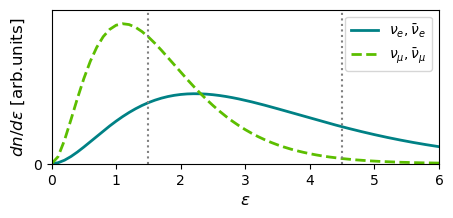

In [7]:
ic_plot(coherent, eps_data)

The number density distribution is shown in the figure above. The dotted lines at $\epsilon = 1.5$ and $\epsilon = 4.5$ will indicate two exemplar bins that we will explore. We choose these becasue for $\epsilon = 1.5$ there are more $\nu_\mu$ than $\nu_e$ and vice versa for $\epsilon = 4.5$, so we can exhibit the largely-complementary behavior of both.

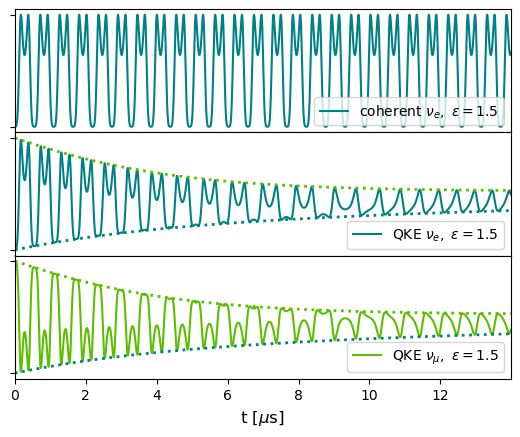

In [9]:
coherent_comp_numu(coherent, QKE, thermal, eps_data)

The figure above shows the evolution of the number density distribution at $\epsilon = 1.5$ for $\nu_e$ in the coherent case (top); for $\nu_e$ in the QKE solution (middle); and $\nu_\mu$ in the QKE solution (bottom). In the QKE solutions, the purely thermal solution is indicated by the dotted lines for both $\nu_e$ (blue) and $\nu_\mu$ (green)

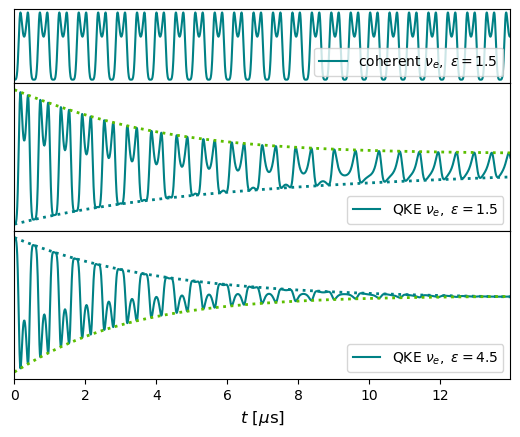

In [11]:
coherent_comp_nrg(coherent, QKE, thermal, eps_data)

The figure above shows the evolution of $\epsilon = 1.5$ and $\epsilon = 4.5$ for the $\nu_e$ distribution. Again, the dotted lines are the purely kinetic solution.

To study the synchronous oscillations, we look at the density term in the Hamiltonian,
$$H = \sqrt{2} G_F T_{\rm cm}^3 \int_0^\infty \frac{\epsilon^2 d \epsilon}{2 \pi^2} \big( \rho - \bar\rho \big) \equiv \tfrac{1}{2} H_0 I + \tfrac{1}{2} \vec{\mathbf{V}} \cdot \vec{\sigma}$$

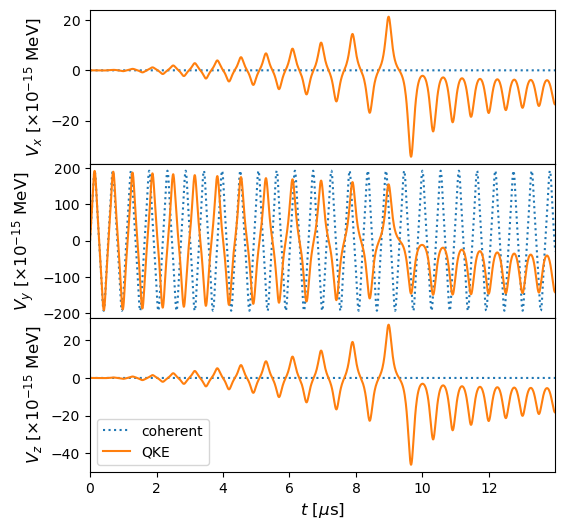

In [14]:
Vxyz_plot(coherent, QKE, eps_data)

The figure above shows the evolution of the components of $\vec{\mathbf{V}}$ as a function of time for the coherent solution (dotted) and the QKE solution (solid). $V_x$ and $V_z$ are identically zero at all times for the coherent solution.

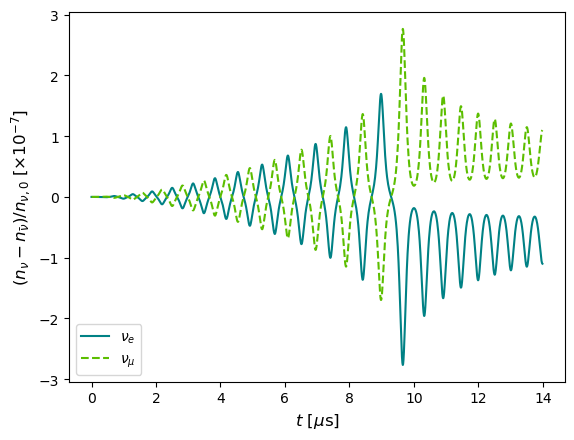

In [16]:
plot_nd_asymmetry(QKE, eps_data)

The plot above shows the evolution of the asymmetry between neutrinos and antineutrinos of each flavor.

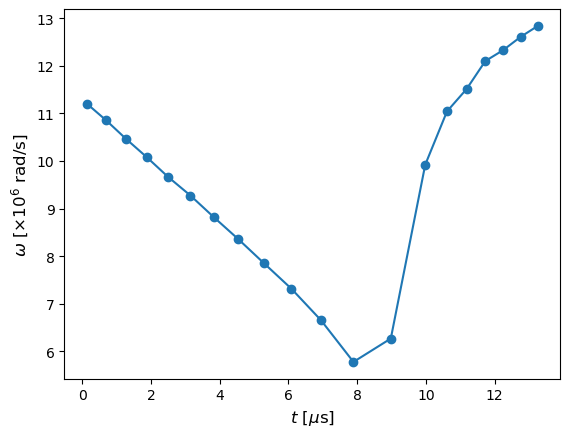

In [18]:
plot_osc_freq(QKE, eps_data)

The plot above show the oscillation frequency, estimated from the peaks of $V_y$.

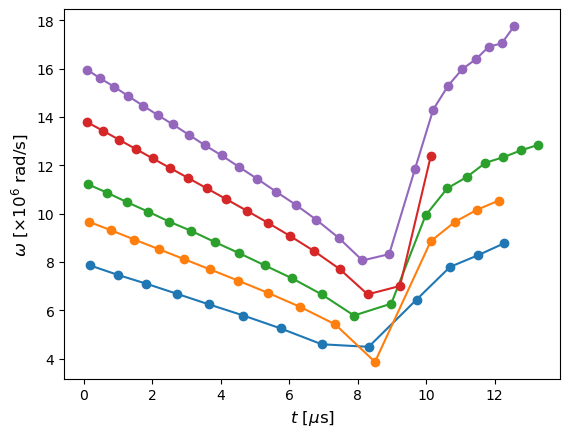

In [20]:
plot_osc_freq_models(mult_data, eps_data, just_down=False)

The figure above shows the oscillation frequencies, but now run for a range of models (set by different values of $\Delta m^2$. (Green model--the middle one--is the same as the results above.)

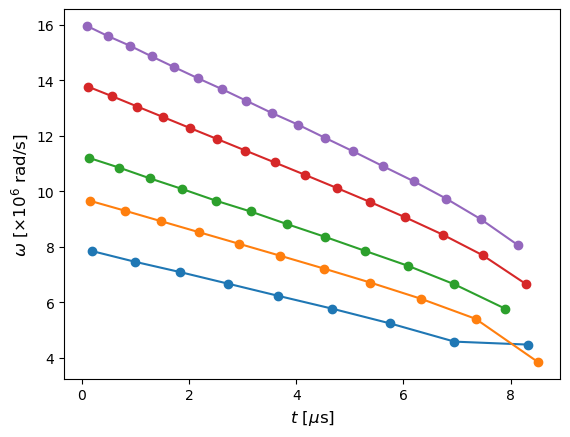

In [22]:
plot_osc_freq_models(mult_data, eps_data)

The figure above focuses just on the range of times where the frequency is decreasing